## Tourism Experience Analytics

### Github

https://github.com/aniket010011/Intern-Projects

### Problem Description

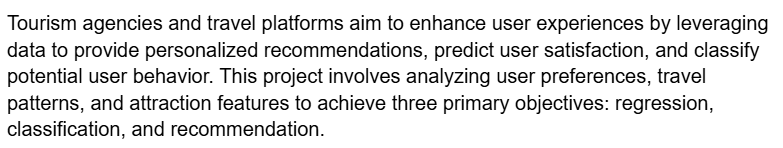

### Objectives

Predict attractions based on historical user activity

Analyse and suggest insights on popular attractions and regions

Perform segmentation of users and help in remarketing campaigns

Predict personalized recommendations to help in customer retention

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression, LinearRegression
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import precision_recall_curve, accuracy_score, roc_auc_score, roc_curve, auc, classification_report, confusion_matrix, f1_score, r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

Load Data

In [2]:
transactions = pd.read_excel("/content/Transaction.xlsx")
users = pd.read_excel("/content/User.xlsx")
cities = pd.read_excel("/content/City.xlsx")
countries = pd.read_excel("/content/Country.xlsx")
regions = pd.read_excel("/content/Region.xlsx")
continents = pd.read_excel("/content/Continent.xlsx")
attractions = pd.read_excel("/content/Item.xlsx")
attraction_types = pd.read_excel("/content/Type.xlsx")
visit_modes = pd.read_excel("/content/Mode.xlsx")

Checking Dataset

In [3]:
print(transactions.columns)
print(transactions.head())
print(transactions.shape)

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode',
       'AttractionId', 'Rating'],
      dtype='object')
   TransactionId  UserId  VisitYear  VisitMonth  VisitMode  AttractionId  \
0              3   70456       2022          10          2           640   
1              8    7567       2022          10          4           640   
2              9   79069       2022          10          3           640   
3             10   31019       2022          10          3           640   
4             15   43611       2022          10          2           640   

   Rating  
0       5  
1       5  
2       5  
3       3  
4       3  
(52930, 7)


### Data Cleaning and Preprocessing

Transactions Data

In [4]:
transactions.columns = transactions.columns.str.strip()

transactions.drop_duplicates(inplace=True)

transactions["Rating"] = pd.to_numeric(transactions["Rating"], errors="coerce")
transactions = transactions[(transactions["Rating"] >= 1) & (transactions["Rating"] <= 5)]

transactions["VisitYear"] = pd.to_numeric(transactions["VisitYear"], errors="coerce")
transactions["VisitMonth"] = pd.to_numeric(transactions["VisitMonth"], errors="coerce")
transactions = transactions[(transactions["VisitMonth"] >= 1) & (transactions["VisitMonth"] <= 12)]

transactions["VisitMode"] = transactions["VisitMode"].astype(str).str.strip().str.title()

User Data

In [5]:
users.columns = users.columns.str.strip()
users.drop_duplicates(subset="UserId", inplace=True)

for col in ["ContinentId","RegionId","CountryId","CityId"]:
    users[col] = pd.to_numeric(users[col], errors="coerce")

City Data

In [6]:
cities.columns = cities.columns.str.strip()
cities.drop_duplicates(subset="CityId", inplace=True)
cities["CityName"] = cities["CityName"].astype(str).str.strip().str.title()

Country Data

In [7]:
countries.columns = countries.columns.str.strip()
countries.drop_duplicates(subset="CountryId", inplace=True)
countries["Country"] = countries["Country"].astype(str).str.strip().str.title()

Region Data

In [8]:
regions.columns = regions.columns.str.strip()
regions.drop_duplicates(subset="RegionId", inplace=True)
regions["Region"] = regions["Region"].astype(str).str.strip().str.title()

Continent Data

In [9]:
continents.columns = continents.columns.str.strip()
continents.drop_duplicates(subset="ContinentId", inplace=True)
continents["Continent"] = continents["Continent"].astype(str).str.strip().str.title()

Attractions/Item Data

In [10]:
attractions.columns = attractions.columns.str.strip()
attractions.drop_duplicates(subset="AttractionId", inplace=True)

attractions["Attraction"] = attractions["Attraction"].astype(str).str.strip().str.title()
attractions["AttractionAddress"] = attractions["AttractionAddress"].fillna("Unknown")

Attraction Type Data

In [11]:
attraction_types.columns = attraction_types.columns.str.strip()
attraction_types.drop_duplicates(subset="AttractionTypeId", inplace=True)
attraction_types["AttractionType"] = attraction_types["AttractionType"].astype(str).str.strip().str.title()

Mode Data

In [12]:
visit_modes.columns = visit_modes.columns.str.strip()
visit_modes.drop_duplicates(subset="VisitModeId", inplace=True)
visit_modes["VisitMode"] = visit_modes["VisitMode"].astype(str).str.strip().str.title()

Cleaning dataset columns

In [13]:
def clean_cols(df):
    df.columns = df.columns.str.strip()
    return df

transactions = clean_cols(transactions)
users = clean_cols(users)
cities = clean_cols(cities)
countries = clean_cols(countries)
regions = clean_cols(regions)
continents = clean_cols(continents)
attractions = clean_cols(attractions)
attraction_types = clean_cols(attraction_types)
visit_modes = clean_cols(visit_modes)

### Merging into a Master Dataset and further Cleaning

In [14]:
print(transactions.columns)
print(users.columns)
print(cities.columns)
print(countries.columns)
print(regions.columns)
print(continents.columns)
print(attractions.columns)
print(attraction_types.columns)
print(visit_modes.columns)

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode',
       'AttractionId', 'Rating'],
      dtype='object')
Index(['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId'], dtype='object')
Index(['CityId', 'CityName', 'CountryId'], dtype='object')
Index(['CountryId', 'Country', 'RegionId'], dtype='object')
Index(['Region', 'RegionId', 'ContinentId'], dtype='object')
Index(['ContinentId', 'Continent'], dtype='object')
Index(['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction',
       'AttractionAddress'],
      dtype='object')
Index(['AttractionTypeId', 'AttractionType'], dtype='object')
Index(['VisitModeId', 'VisitMode'], dtype='object')


Merging Datasets

In [15]:
# Transactions + Users
master_df = transactions.merge(users, on="UserId", how="left")

# Add City info
master_df = master_df.merge(cities, on="CityId", how="left", suffixes=("", "_City"))

# Add Country info
master_df = master_df.merge(countries, on="CountryId", how="left", suffixes=("", "_Country"))

# Add Region info
master_df = master_df.merge(regions, on="RegionId", how="left", suffixes=("", "_Region"))

# Add Continent info
master_df = master_df.merge(continents, on="ContinentId", how="left")

# Merging Attraction Data
master_df = master_df.merge(attractions, on="AttractionId", how="left")
master_df = master_df.merge(attraction_types, on="AttractionTypeId", how="left")
master_df = master_df.merge(visit_modes, on="VisitMode", how="left")

Verifying Master Dataset

In [16]:
print(master_df.shape)

master_df[[
    "UserId", "CityName", "Country", "Region", "Continent",
    "Attraction", "AttractionType", "VisitMode", "Rating"
]].head()


(52930, 24)


,UserId,CityName,Country,Region,Continent,Attraction,AttractionType,VisitMode,Rating
0,70456,Guildford,United Kingdom,Western Europe,Europe,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,2,5
1,7567,Ontario,Canada,Northern America,America,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,4,5
2,79069,Brazil,Brazil,South America,America,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,3,5
3,31019,Zurich,Switzerland,Central Europe,Europe,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,3,3
4,43611,Manchester,United Kingdom,Western Europe,Europe,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,2,3


Dropping any Duplicate rows

In [17]:
master_df.drop_duplicates(inplace=True)

print("After removing duplicates:", master_df.shape)

After removing duplicates: (52930, 24)


Checking Missing Values

In [18]:
missing = master_df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

VisitModeId       52930
CityId                8
CityName              8
CountryId_City        8
dtype: int64


Addressing Missing Values in Columns

In [19]:
geo_cols = ["CityName", "Country", "Region", "Continent"]
for col in geo_cols:
    master_df[col].fillna("Unknown", inplace=True)


In [20]:
master_df["AttractionType"].fillna("Other", inplace=True)
master_df["AttractionAddress"].fillna("Unknown", inplace=True)

In [21]:
master_df = master_df[master_df["Rating"].notnull()]

Standardizing Datatype

In [22]:
master_df["Rating"] = master_df["Rating"].astype(float)
master_df["VisitYear"] = master_df["VisitYear"].astype(int)
master_df["VisitMonth"] = master_df["VisitMonth"].astype(int)

In [23]:
master_df["VisitMode"] = master_df["VisitMode"].str.strip().str.title()

Checking Dataset

In [24]:
print(master_df.isnull().sum().sum(), "total missing values left")
master_df.info()

52946 total missing values left
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   TransactionId       52930 non-null  int64  
 1   UserId              52930 non-null  int64  
 2   VisitYear           52930 non-null  int64  
 3   VisitMonth          52930 non-null  int64  
 4   VisitMode           52930 non-null  object 
 5   AttractionId        52930 non-null  int64  
 6   Rating              52930 non-null  float64
 7   ContinentId         52930 non-null  int64  
 8   RegionId            52930 non-null  int64  
 9   CountryId           52930 non-null  int64  
 10  CityId              52922 non-null  float64
 11  CityName            52930 non-null  object 
 12  CountryId_City      52922 non-null  float64
 13  Country             52930 non-null  object 
 14  RegionId_Country    52930 non-null  int64  
 15  Region              5

Removing Unnecessary Columns

In [25]:
cols_to_drop = [
    "VisitModeId",          # completely empty after merging
    "CountryId_City",       # duplicate from city-country merge
    "RegionId_Country",     # duplicate from country-region merge
    "ContinentId_Region"    # duplicate from region-continent merge
]

master_df.drop(columns=cols_to_drop, inplace=True)

Removing Remaining Missing Values

In [26]:
master_df.dropna(subset=["CityId"], inplace=True)

In [27]:
print(master_df.isnull().sum().sum(), "total missing values left")

0 total missing values left


Saving Cleaned Dataset

In [28]:
master_df.to_csv("clean_master_tourism_data.csv", index=False)

### Exploratory Data Analysis

Users by Continent

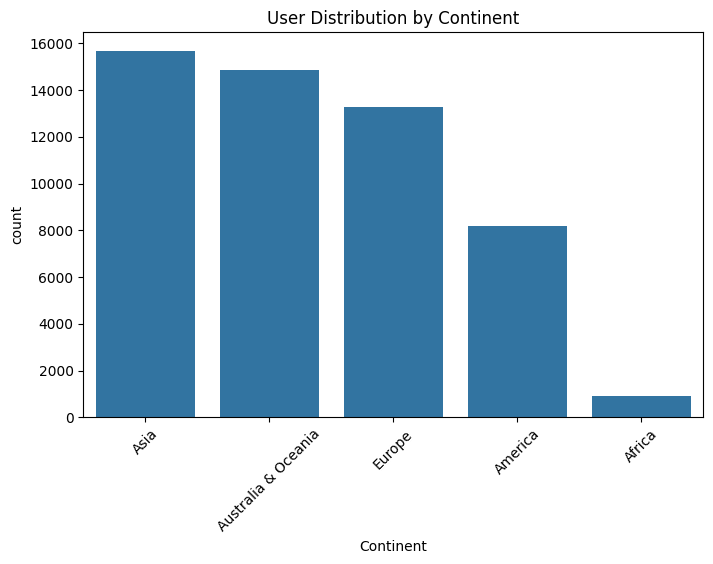

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=master_df, x="Continent", order=master_df["Continent"].value_counts().index)
plt.title("User Distribution by Continent")
plt.xticks(rotation=45)
plt.show()

Tourism platforms can identify strong user bases and target marketing in underrepresented continents.

Users by Country

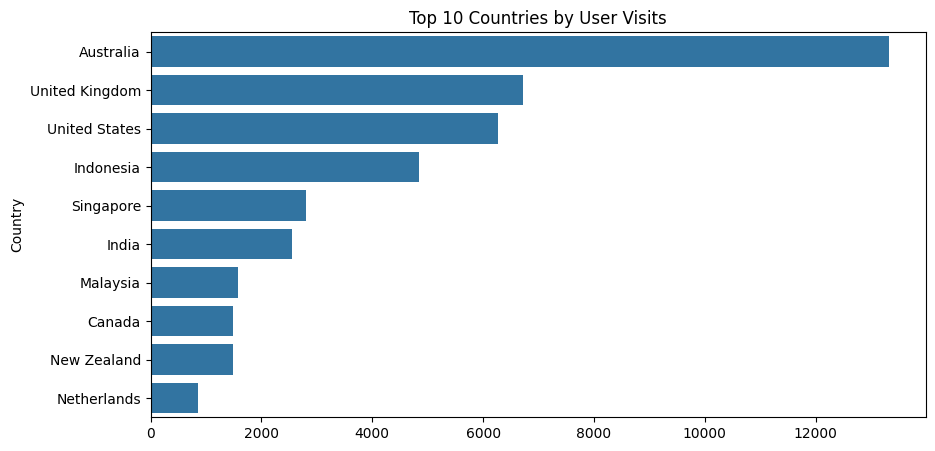

In [30]:
top_countries = master_df["Country"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by User Visits")
plt.show()

Helps tourism agencies focus partnerships and promotions in high-demand countries.

Attraction Type by Popularity

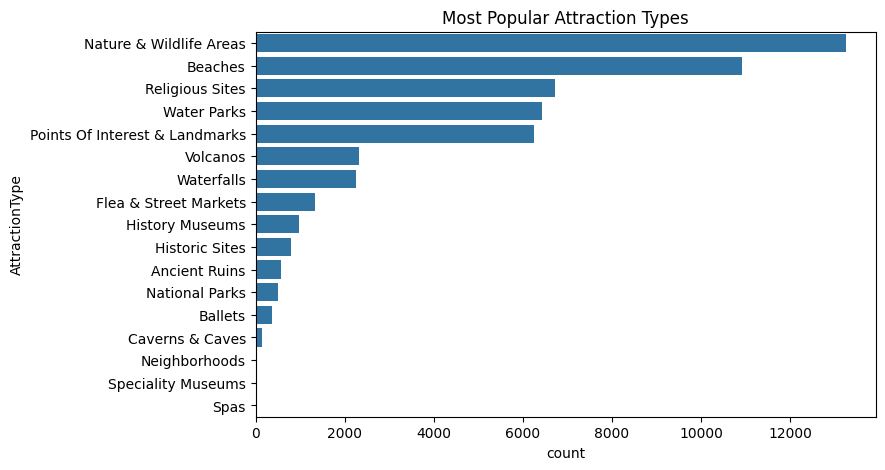

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(data=master_df, y="AttractionType", order=master_df["AttractionType"].value_counts().index)
plt.title("Most Popular Attraction Types")
plt.show()

Shows what experiences users love (e.g., beaches vs museums).

Attraction Types by Ratings

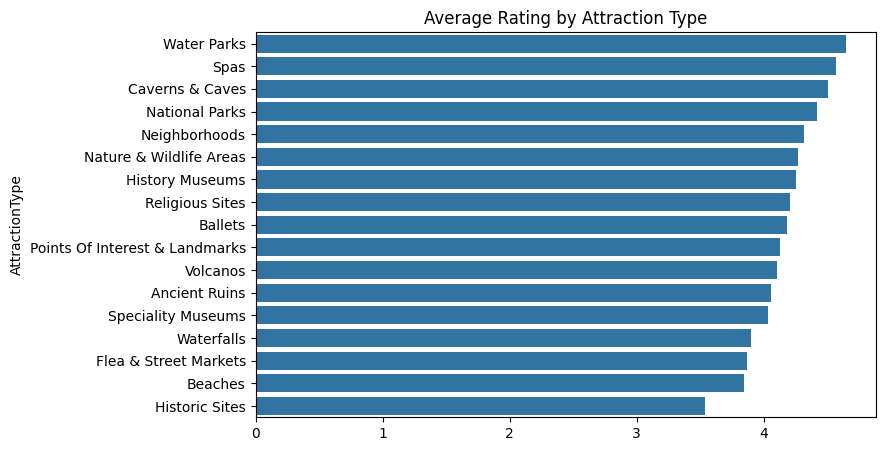

In [32]:
avg_rating = master_df.groupby("AttractionType")["Rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=avg_rating.values, y=avg_rating.index)
plt.title("Average Rating by Attraction Type")
plt.show()

Helps recommend high-satisfaction attraction categories.

Rating Distribution

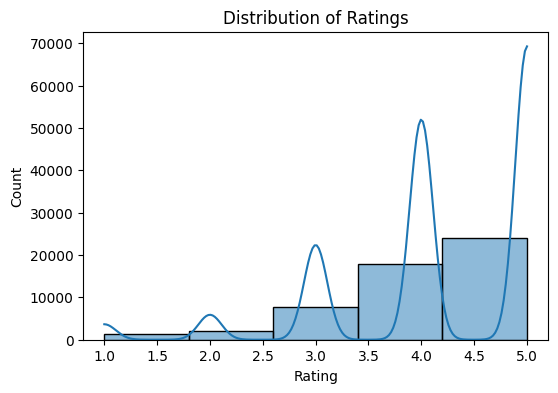

In [33]:
plt.figure(figsize=(6,4))
sns.histplot(master_df["Rating"], bins=5, kde=True)
plt.title("Distribution of Ratings")
plt.show()

Reveals if users are generally satisfied or critical.

Ratings by Continent

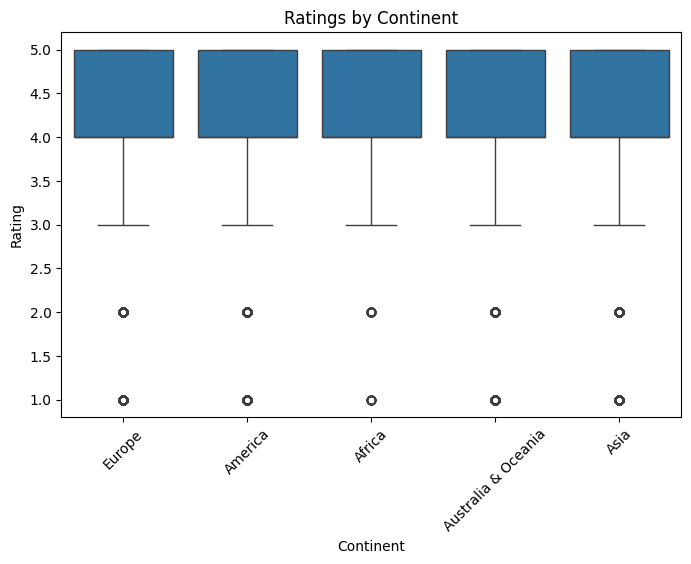

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(data=master_df, x="Continent", y="Rating")
plt.title("Ratings by Continent")
plt.xticks(rotation=45)
plt.show()

Shows regional satisfaction differences.

Visit Mode Distribution

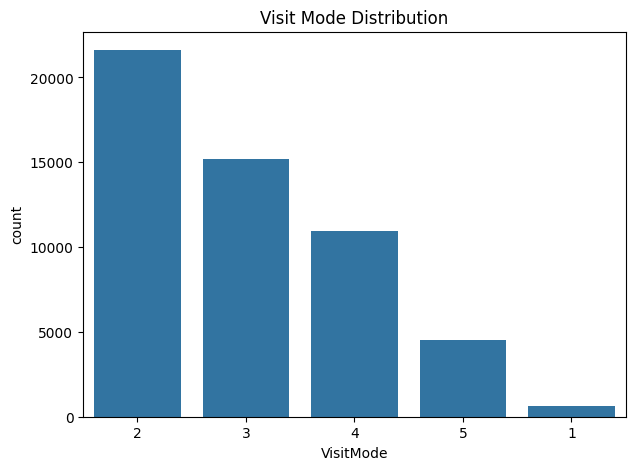

In [35]:
plt.figure(figsize=(7,5))
sns.countplot(data=master_df, x="VisitMode", order=master_df["VisitMode"].value_counts().index)
plt.title("Visit Mode Distribution")
plt.show()

Shows dominant traveler types based on visit mode which is key for classification model.

Visit Mode by Continent

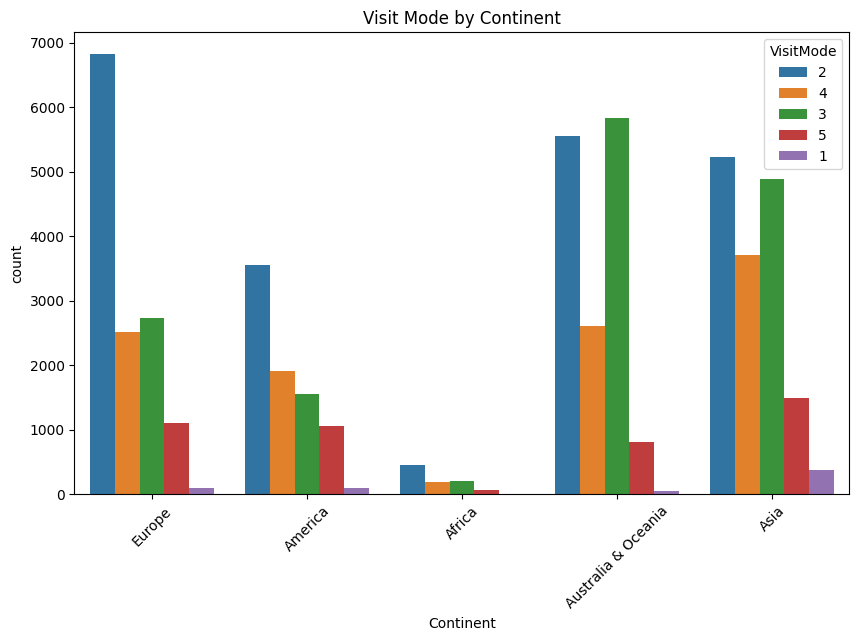

In [36]:
plt.figure(figsize=(10,6))
sns.countplot(data=master_df, x="Continent", hue="VisitMode")
plt.title("Visit Mode by Continent")
plt.xticks(rotation=45)
plt.show()

Different regions prefer different travel styles.

Visits by Month

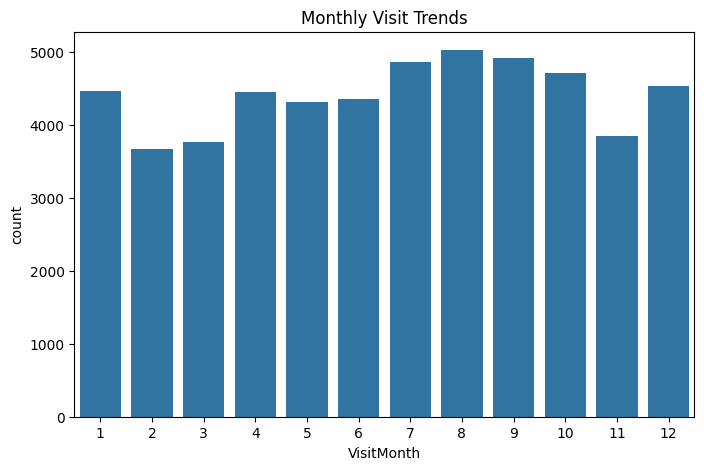

In [37]:
plt.figure(figsize=(8,5))
sns.countplot(data=master_df, x="VisitMonth")
plt.title("Monthly Visit Trends")
plt.show()

Identifies peak tourism seasons.

Visits by Year

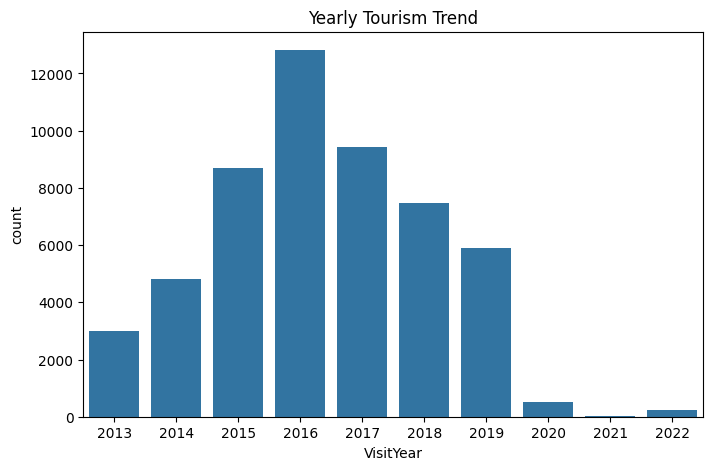

In [38]:
plt.figure(figsize=(8,5))
sns.countplot(data=master_df, x="VisitYear")
plt.title("Yearly Tourism Trend")
plt.show()

Reveals tourism growth or decline over time.

Correlation Heatmap of Numeric Features

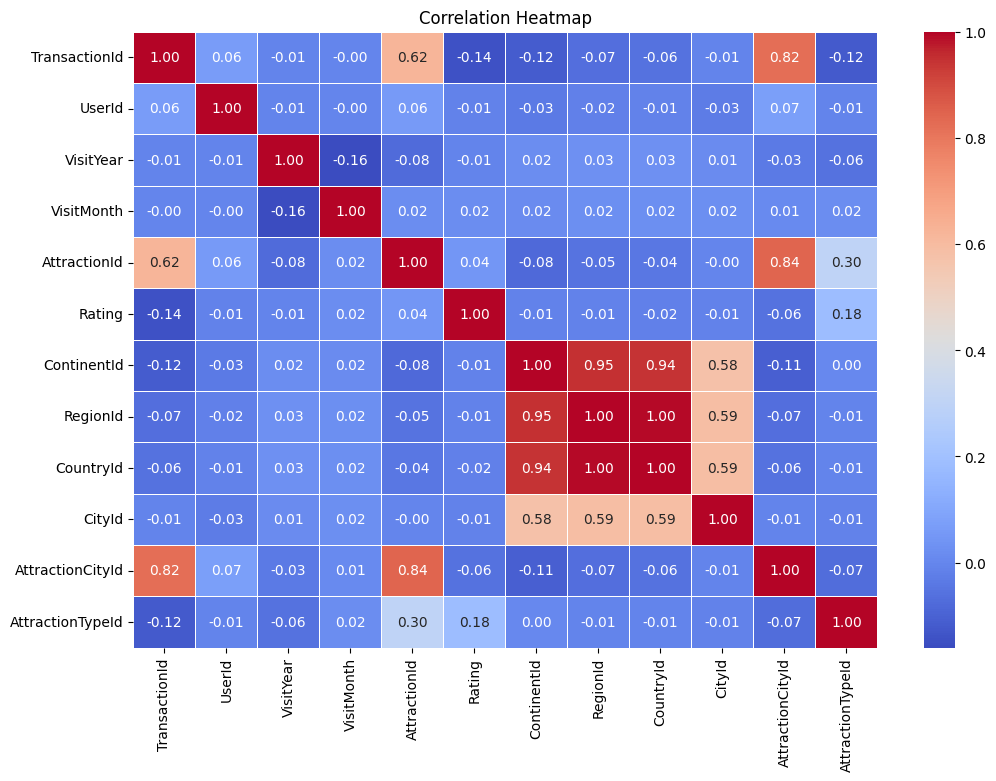

In [39]:
numeric_df = master_df.select_dtypes(include=["int64", "float64"])
numeric_df.head()

corr_matrix = numeric_df.corr()
corr_matrix

plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()


Shows strong positive correlation between the geographic columns of data and their corresponding ID columns

### Preparing Pipelines and Model Building

Data Preparation

In [40]:
drop_cols = [
    "UserId",
    "AttractionId",
    "AttractionCityId",
    "CityName",
    "Attraction",
    "AttractionTypeId",
    "Continent"
]

X = master_df.drop(columns=drop_cols + ["Rating", "VisitMode"])

In [41]:
# Regression target
y_reg = master_df["Rating"]

# Classification target (if needed)
le = LabelEncoder()
y_clf_encoded = le.fit_transform(master_df["VisitMode"])

In [42]:
print("Final features used by model:")
print(X.columns.tolist())

Final features used by model:
['TransactionId', 'VisitYear', 'VisitMonth', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'Country', 'Region', 'AttractionAddress', 'AttractionType']


In [43]:
drop_cols = [
    # user / ids
    "UserId",
    "TransactionId",
    "AttractionId",
    "AttractionCityId",
    "CityId",
    "CountryId",
    "RegionId",
    "ContinentId",

    # high-cardinality text
    "CityName",
    "Attraction",
    "AttractionAddress",

    # redundant ids
    "AttractionTypeId",
    "Continent"
]

In [44]:
X = master_df.drop(columns=drop_cols + ["Rating", "VisitMode"])

In [45]:
print("Final features used by model:")
print(X.columns.tolist())

Final features used by model:
['VisitYear', 'VisitMonth', 'Country', 'Region', 'AttractionType']


In [46]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

Categorical: ['Country', 'Region', 'AttractionType']
Numerical: ['VisitYear', 'VisitMonth']


In [47]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

Train Test Split

In [48]:
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf_encoded, test_size=0.2, random_state=42
)

Regression Model Pipelines

In [49]:
reg_models = {
    "LinearRegression": LinearRegression(),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    ),

    "LightGBM": lgb.LGBMRegressor(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    )
}


Regression Training and Evaluation

In [50]:
reg_results = []

for name, model in reg_models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_reg_train)
    preds = pipeline.predict(X_test)

    reg_results.append({
        "Model": name,
        "R2": r2_score(y_reg_test, preds),
        "RMSE": mean_squared_error(y_reg_test, preds) ** 0.5
    })

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001296 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 246
[LightGBM] [Info] Number of data points in the train set: 42337, number of used features: 113
[LightGBM] [Info] Start training from score 4.156648


In [51]:
reg_results_df = pd.DataFrame(reg_results)
reg_results_df

,Model,R2,RMSE
0,LinearRegression,0.075499,0.937226
1,XGBoost,0.094926,0.927326
2,LightGBM,0.096234,0.926656


Visualization of Model Performance

R2 Score

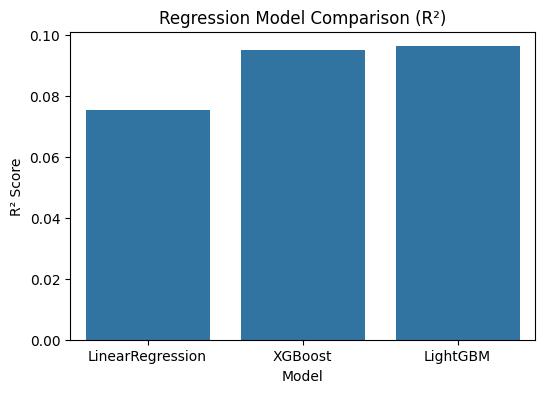

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(data=reg_results_df, x="Model", y="R2")
plt.title("Regression Model Comparison (R²)")
plt.ylabel("R² Score")
plt.show()

RMSE Comparison

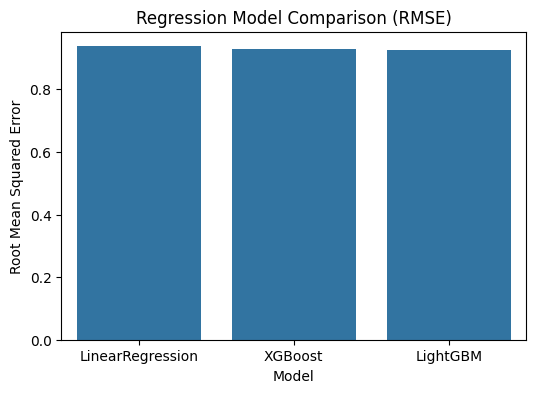

In [53]:
plt.figure(figsize=(6,4))
sns.barplot(data=reg_results_df, x="Model", y="RMSE")
plt.title("Regression Model Comparison (RMSE)")
plt.ylabel("Root Mean Squared Error")
plt.show()

Actual vs Predicted

In [54]:
## Retraining
best_reg_model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_reg_model)
])

best_pipeline.fit(X_train, y_reg_train)
y_pred_best = best_pipeline.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000671 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 246
[LightGBM] [Info] Number of data points in the train set: 42337, number of used features: 113
[LightGBM] [Info] Start training from score 4.156648


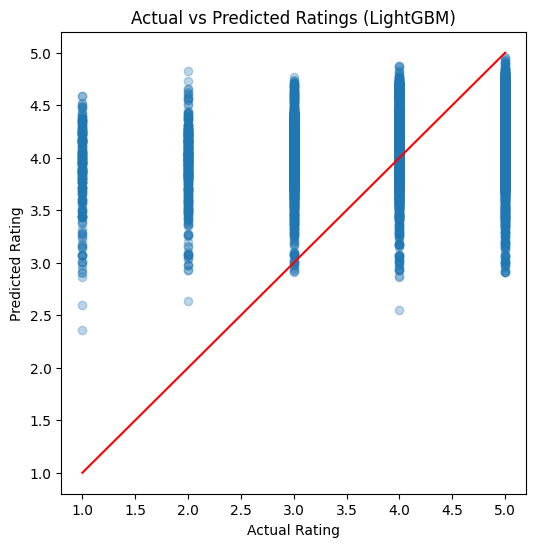

In [55]:
plt.figure(figsize=(6,6))
plt.scatter(y_reg_test, y_pred_best, alpha=0.3)
plt.plot([1,5], [1,5], color="red")  # ideal prediction line
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings (LightGBM)")
plt.show()

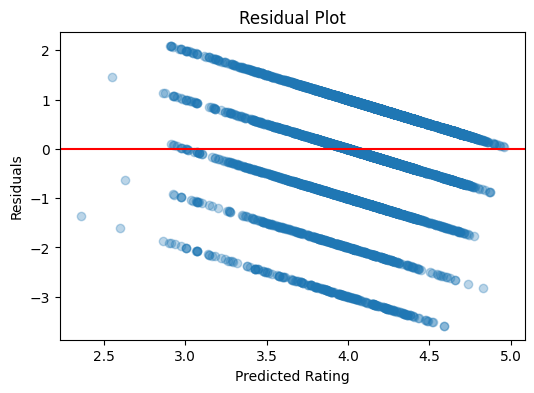

In [56]:
residuals = y_reg_test - y_pred_best

plt.figure(figsize=(6,4))
plt.scatter(y_pred_best, residuals, alpha=0.3)
plt.axhline(y=0, color="red")
plt.xlabel("Predicted Rating")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

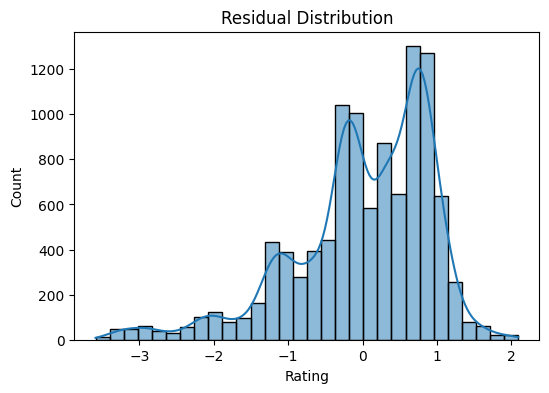

In [57]:
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residual Distribution")
plt.show()

Classification Model Pipelines

In [58]:
clf_models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        multi_class="auto"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        eval_metric="mlogloss",
        random_state=42
    ),

    "LightGBM": lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    )
}

Classification Training and Evaluation

In [59]:
clf_results = []

for name, model in clf_models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_clf_train)
    preds = pipeline.predict(X_test)

    clf_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_clf_test, preds),
        "F1_weighted": f1_score(y_clf_test, preds, average="weighted")
    })

    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_clf_test, preds))


LogisticRegression Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       135
           1       0.47      0.84      0.61      4337
           2       0.50      0.33      0.40      2995
           3       0.34      0.13      0.19      2190
           4       0.33      0.01      0.01       928

    accuracy                           0.47     10585
   macro avg       0.33      0.26      0.24     10585
weighted avg       0.43      0.47      0.40     10585


XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.03      0.06       135
           1       0.49      0.83      0.61      4337
           2       0.52      0.40      0.46      2995
           3       0.40      0.15      0.22      2190
           4       0.62      0.03      0.06       928

    accuracy                           0.49     10585
   macro avg       0.57      0.29      0.28     10585


In [60]:
clf_results_df = pd.DataFrame(clf_results)
clf_results_df

,Model,Accuracy,F1_weighted
0,LogisticRegression,0.466698,0.400862
1,XGBoost,0.488427,0.432123
2,LightGBM,0.492584,0.445545


Visualizing Model Performance

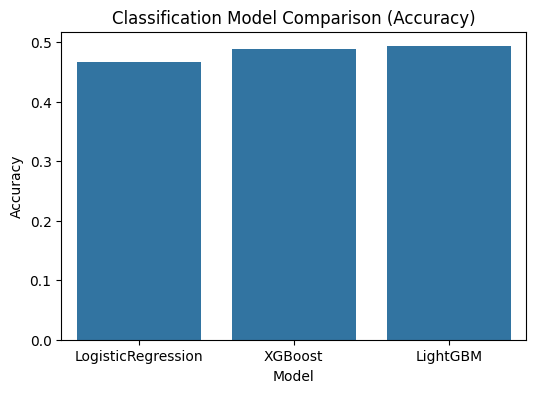

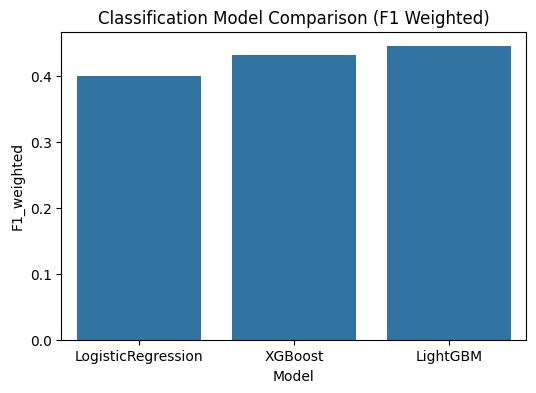

In [61]:
plt.figure(figsize=(6,4))
sns.barplot(data=clf_results_df, x="Model", y="Accuracy")
plt.title("Classification Model Comparison (Accuracy)")
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(data=clf_results_df, x="Model", y="F1_weighted")
plt.title("Classification Model Comparison (F1 Weighted)")
plt.show()

In [62]:
## Retraining
best_clf_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

best_clf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_clf_model)
])

best_clf_pipeline.fit(X_train, y_clf_train)

y_pred_best = best_clf_pipeline.predict(X_test)
y_proba_best = best_clf_pipeline.predict_proba(X_test)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001220 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 246
[LightGBM] [Info] Number of data points in the train set: 42337, number of used features: 113
[LightGBM] [Info] Start training from score -4.463101
[LightGBM] [Info] Start training from score -0.896112
[LightGBM] [Info] Start training from score -1.242587
[LightGBM] [Info] Start training from score -1.576151
[LightGBM] [Info] Start training from score -2.466117


Confusion Matrix(Actual vs Predicted)

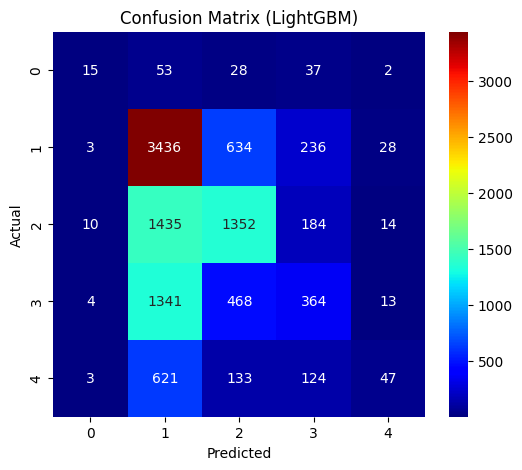

In [63]:
cm = confusion_matrix(y_clf_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="jet")
plt.title("Confusion Matrix (LightGBM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Confusion Matrix(Normalized)

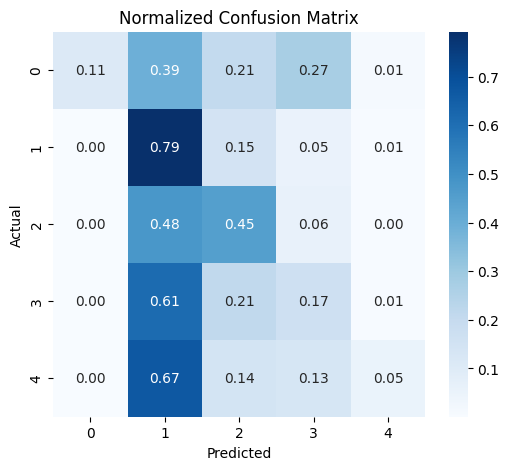

In [64]:
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, None]

plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues")
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Multiclass ROC-AUC Curve

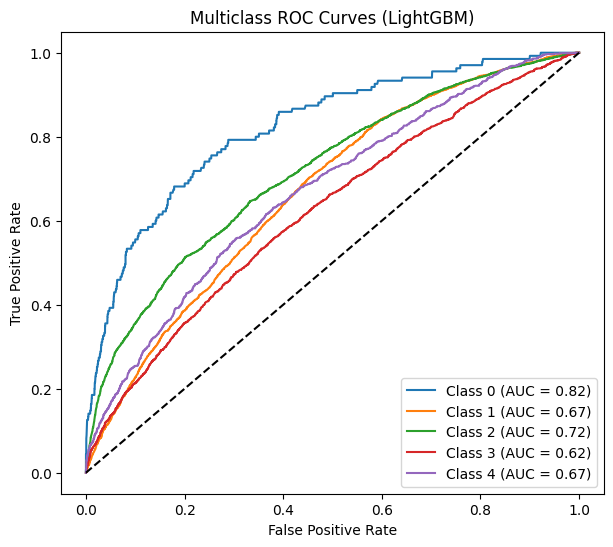

In [65]:
# Binarize labels
n_classes = len(np.unique(y_clf_test))
y_test_bin = label_binarize(y_clf_test, classes=np.arange(n_classes))

plt.figure(figsize=(7,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_best[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves (LightGBM)")
plt.legend()
plt.show()

Precision-Recall Curve

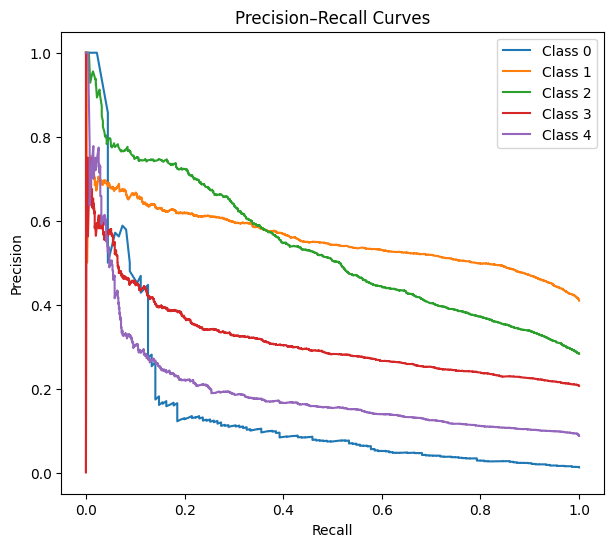

In [66]:
plt.figure(figsize=(7,6))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_proba_best[:, i]
    )
    plt.plot(recall, precision, label=f"Class {i}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.show()

### Building Recommendation System

Preparing Data

In [67]:
# interaction table
rec_df = master_df[["UserId","AttractionId","Attraction","Rating"]].copy()

user_item_matrix = rec_df.pivot_table(
    index="UserId",
    columns="AttractionId",
    values="Rating"
)

user_item_matrix_filled = user_item_matrix.fillna(0)

from sklearn.metrics.pairwise import cosine_similarity
user_similarity = cosine_similarity(user_item_matrix_filled)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix_filled.index,
    columns=user_item_matrix_filled.index
)

Checking Data

In [68]:
print(rec_df.shape)
rec_df.head()

(52922, 4)


,UserId,AttractionId,Attraction,Rating
0,70456,640,Sacred Monkey Forest Sanctuary,5.0
1,7567,640,Sacred Monkey Forest Sanctuary,5.0
2,79069,640,Sacred Monkey Forest Sanctuary,5.0
3,31019,640,Sacred Monkey Forest Sanctuary,3.0
4,43611,640,Sacred Monkey Forest Sanctuary,3.0


Checking User–Item Matrix

In [69]:
print(user_item_matrix_filled.shape)

(33526, 30)


Recommendation Function

In [70]:
def recommend_attractions(user_id, top_n=5):

    # Cold start
    if user_id not in user_item_matrix_filled.index:
        return popularity_fallback(top_n)

    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:21]

    user_rated = user_item_matrix_filled.loc[user_id]
    unrated_items = user_rated[user_rated == 0].index

    scores = {}

    for item in unrated_items:
        weighted_sum = 0
        sim_sum = 0

        for sim_user, sim_score in similar_users.items():
            rating = user_item_matrix_filled.loc[sim_user, item]
            if rating > 0 and sim_score > 0:
                weighted_sum += sim_score * rating
                sim_sum += sim_score

        if sim_sum > 0:
            scores[item] = weighted_sum / sim_sum

    # CRITICAL FALLBACK
    if len(scores) == 0:
        return popularity_fallback(top_n)

    top_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    top_ids = [item[0] for item in top_items]

    recommendations = (
        rec_df[rec_df["AttractionId"].isin(top_ids)]
        [["AttractionId", "Attraction"]]
        .drop_duplicates()
    )

    return recommendations

Creating User Fallback

In [71]:
def popularity_fallback(top_n=5):
    popular = (
        rec_df.groupby("Attraction")["Rating"]
        .count()
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index(name="VisitCount")
    )
    return popular

Testing and Checking Recommender

In [72]:
sample_user = user_item_matrix_filled.index[0]
recommend_attractions(sample_user, top_n=5)

,Attraction,VisitCount
0,Sacred Monkey Forest Sanctuary,13197
1,Waterbom Bali,6429
2,Tegalalang Rice Terrace,5811
3,Uluwatu Temple,3359
4,Tanah Lot Temple,3352


In [73]:
user_id = sample_user

user_rated = user_item_matrix_filled.loc[user_id]
print("User rated count:", (user_rated > 0).sum())
print("Total items:", len(user_rated))

User rated count: 2
Total items: 30


In [74]:
for uid in user_item_matrix_filled.index[:10]:
    recs = recommend_attractions(uid, top_n=5)
    print(uid, len(recs))

14 5
16 4
20 5
23 5
25 5
26 5
27 5
28 5
29 5
32 5


Building Hybrid Recommender

Preparing Data with TF-IDF Vectorization

In [75]:
item_features = master_df[[
    "AttractionId",
    "Attraction",
    "AttractionType",
    "CityName",
    "Country",
    "Region",
    "Continent"
]].drop_duplicates()

item_features["content"] = (
    item_features["AttractionType"].astype(str) + " " +
    item_features["CityName"].astype(str) + " " +
    item_features["Country"].astype(str) + " " +
    item_features["Region"].astype(str) + " " +
    item_features["Continent"].astype(str)
)

tfidf = TfidfVectorizer(stop_words="english")
content_matrix = tfidf.fit_transform(item_features["content"])

In [76]:
item_features = item_features.reset_index(drop=True)

In [77]:
item_id_to_pos = {
    aid: idx for idx, aid in enumerate(item_features["AttractionId"])
}

Item Similarity Function

In [78]:
def get_similar_items(item_id, top_k=20):

    if item_id not in item_id_to_pos:
        return pd.DataFrame(columns=["AttractionId", "Attraction"])

    idx = item_id_to_pos[item_id]

    sim_scores = cosine_similarity(
        content_matrix[idx],
        content_matrix
    ).flatten()

    top_indices = sim_scores.argsort()[::-1][1:top_k+1]

    return item_features.iloc[top_indices][["AttractionId", "Attraction"]]

Content Recommender Function

In [79]:
def content_recommend(user_id, top_n=10):

    if user_id not in user_item_matrix_filled.index:
        return popularity_fallback(top_n)

    user_ratings = user_item_matrix_filled.loc[user_id]
    liked_items = user_ratings[user_ratings >= 4].index

    if len(liked_items) == 0:
        return popularity_fallback(top_n)

    recs = []

    for item in liked_items[:3]:  # limit for speed
        similar = get_similar_items(item, top_k=top_n)
        recs.append(similar)

    content_recs = pd.concat(recs).drop_duplicates().head(top_n)

    return content_recs

Checking Prepared Data

In [80]:
print("Users:", user_item_matrix_filled.shape[0])
print("Items:", user_item_matrix_filled.shape[1])
print("Item features:", item_features.shape)

Users: 33526
Items: 30
Item features: (14803, 8)


Building Hybrid Recommender

In [81]:
def hybrid_recommend(user_id, top_n=5, alpha=0.6, beta=0.4):

    # --- CF ---
    cf_recs = recommend_attractions(user_id, top_n=top_n*3)

    if "AttractionId" not in cf_recs.columns:
        cf_recs = popularity_fallback(top_n*3)

    cf_recs = cf_recs[["AttractionId", "Attraction"]].copy()
    cf_recs["score"] = alpha

    # --- Content ---
    content_recs = content_recommend(user_id, top_n=top_n*3)

    content_recs = content_recs[["AttractionId", "Attraction"]].copy()
    content_recs["score"] = beta

    # --- Combine ---
    combined = pd.concat([cf_recs, content_recs], ignore_index=True)

    final = (
        combined.groupby(["AttractionId", "Attraction"])["score"]
        .sum()
        .reset_index()
        .sort_values("score", ascending=False)
        .head(top_n)
    )

    # safety fallback
    if len(final) == 0:
        return popularity_fallback(top_n)

    return final[["AttractionId", "Attraction"]]

Creating Popularity Fallback

In [82]:
def popularity_fallback(top_n=5):

    popular = (
        rec_df.groupby(["AttractionId", "Attraction"])["Rating"]
        .count()
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index(name="VisitCount")
    )

    return popular

Outout Sample Shape of Recommenders

In [83]:
sample_user = user_item_matrix_filled.index[0]

cf_recs = recommend_attractions(sample_user, top_n=5)
content_recs = content_recommend(sample_user, top_n=5)
hybrid_recs = hybrid_recommend(sample_user, top_n=5)

print("CF:", cf_recs.shape)
print("Content:", content_recs.shape)
print("Hybrid:", hybrid_recs.shape)

CF: (5, 3)
Content: (3, 2)
Hybrid: (5, 2)


Summarized Tabular View of Recommenders

In [84]:
def display_recs(title, df):
    print(f"\n===== {title} =====")
    display(df.reset_index(drop=True))

display_recs("Collaborative Filtering", cf_recs)
display_recs("Content-Based", content_recs)
display_recs("Hybrid Recommender", hybrid_recs)


===== Collaborative Filtering =====


,AttractionId,Attraction,VisitCount
0,640,Sacred Monkey Forest Sanctuary,13197
1,841,Waterbom Bali,6429
2,748,Tegalalang Rice Terrace,5811
3,824,Uluwatu Temple,3359
4,737,Tanah Lot Temple,3352



===== Content-Based =====


,AttractionId,Attraction
0,748,Tegalalang Rice Terrace
1,640,Sacred Monkey Forest Sanctuary
2,824,Uluwatu Temple



===== Hybrid Recommender =====


,AttractionId,Attraction
0,640,Sacred Monkey Forest Sanctuary
1,650,Sanur Beach
2,673,Seminyak Beach
3,737,Tanah Lot Temple
4,748,Tegalalang Rice Terrace


Recommender Count Comparison

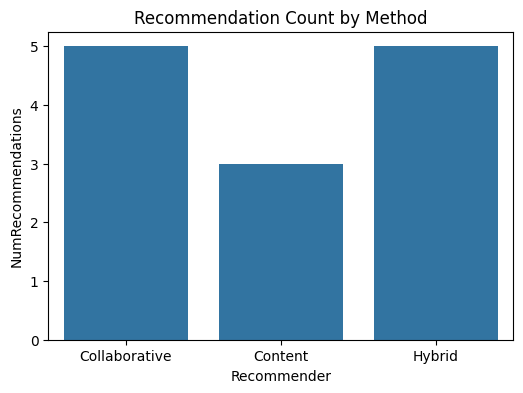

In [85]:
counts_df = pd.DataFrame({
    "Recommender": ["Collaborative", "Content", "Hybrid"],
    "NumRecommendations": [
        len(cf_recs),
        len(content_recs),
        len(hybrid_recs)
    ]
})

plt.figure(figsize=(6,4))
sns.barplot(data=counts_df, x="Recommender", y="NumRecommendations")
plt.title("Recommendation Count by Method")
plt.show()

Recommender Diversity Comparison

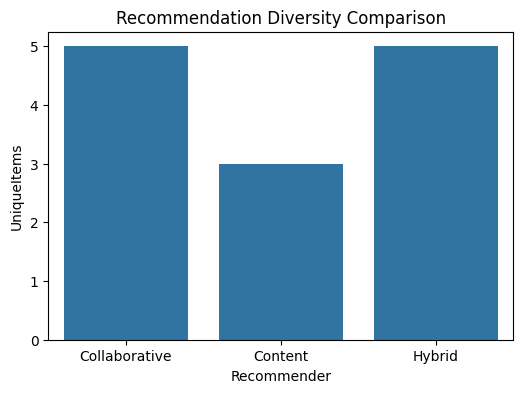

In [86]:
cf_set = set(cf_recs["Attraction"])
content_set = set(content_recs["Attraction"])
hybrid_set = set(hybrid_recs["Attraction"])

diversity_df = pd.DataFrame({
    "Recommender": ["Collaborative", "Content", "Hybrid"],
    "UniqueItems": [
        len(cf_set),
        len(content_set),
        len(hybrid_set)
    ]
})

plt.figure(figsize=(6,4))
sns.barplot(data=diversity_df, x="Recommender", y="UniqueItems")
plt.title("Recommendation Diversity Comparison")
plt.show()

Recommender Overlap Analysis

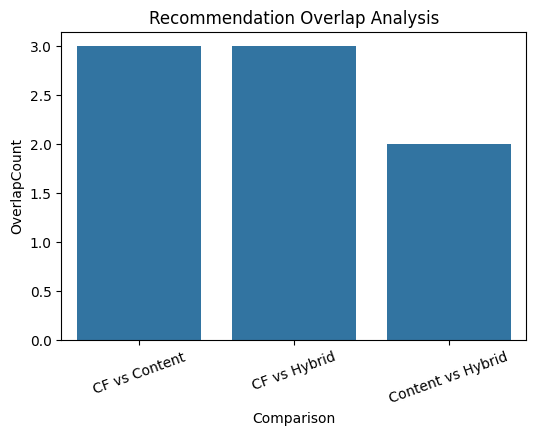

In [87]:
overlap_cf_content = len(cf_set & content_set)
overlap_cf_hybrid = len(cf_set & hybrid_set)
overlap_content_hybrid = len(content_set & hybrid_set)

overlap_df = pd.DataFrame({
    "Comparison": [
        "CF vs Content",
        "CF vs Hybrid",
        "Content vs Hybrid"
    ],
    "OverlapCount": [
        overlap_cf_content,
        overlap_cf_hybrid,
        overlap_content_hybrid
    ]
})

plt.figure(figsize=(6,4))
sns.barplot(data=overlap_df, x="Comparison", y="OverlapCount")
plt.title("Recommendation Overlap Analysis")
plt.xticks(rotation=20)
plt.show()

Popularity Bias Check

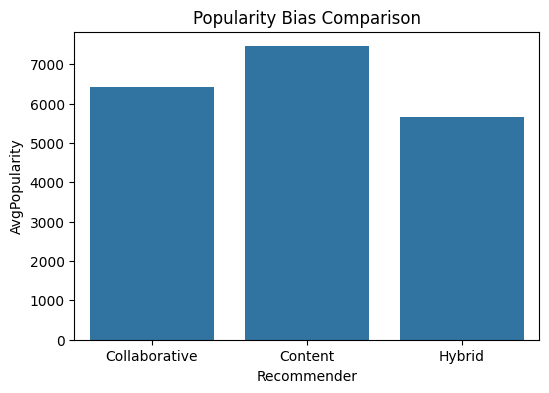

In [88]:
# build popularity lookup
popularity_lookup = (
    rec_df.groupby("Attraction")["Rating"]
    .count()
    .to_dict()
)

def avg_popularity(df):
    return df["Attraction"].map(popularity_lookup).mean()

pop_bias_df = pd.DataFrame({
    "Recommender": ["Collaborative", "Content", "Hybrid"],
    "AvgPopularity": [
        avg_popularity(cf_recs),
        avg_popularity(content_recs),
        avg_popularity(hybrid_recs)
    ]
})

plt.figure(figsize=(6,4))
sns.barplot(data=pop_bias_df, x="Recommender", y="AvgPopularity")
plt.title("Popularity Bias Comparison")
plt.show()

Saving Models

In [89]:
import os
os.makedirs("artifacts", exist_ok=True)

Refitting Best ML Models

In [90]:
best_reg_model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

best_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_reg_model)
])

best_reg_pipeline.fit(X_train, y_reg_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000692 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 246
[LightGBM] [Info] Number of data points in the train set: 42337, number of used features: 113
[LightGBM] [Info] Start training from score 4.156648


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['VisitYear', 'VisitMonth']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Country', 'Region',
                                                   'AttractionType'])])),
                ('model', LGBMRegressor(n_estimators=200, random_state=42))])

In [91]:
best_clf_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

best_clf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_clf_model)
])

best_clf_pipeline.fit(X_train, y_clf_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003058 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 246
[LightGBM] [Info] Number of data points in the train set: 42337, number of used features: 113
[LightGBM] [Info] Start training from score -4.463101
[LightGBM] [Info] Start training from score -0.896112
[LightGBM] [Info] Start training from score -1.242587
[LightGBM] [Info] Start training from score -1.576151
[LightGBM] [Info] Start training from score -2.466117


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['VisitYear', 'VisitMonth']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Country', 'Region',
                                                   'AttractionType'])])),
                ('model', LGBMClassifier(n_estimators=200, random_state=42))])

Saving Regression and Classification Models

In [92]:
joblib.dump(best_reg_pipeline, "artifacts/regression_pipeline.pkl")
joblib.dump(best_clf_pipeline, "artifacts/classification_pipeline.pkl")

['artifacts/classification_pipeline.pkl']

Saving Label Encoder

In [93]:
joblib.dump(le, "artifacts/label_encoder.pkl")

['artifacts/label_encoder.pkl']

Saving Recommenders

In [94]:
joblib.dump(tfidf, "artifacts/tfidf_vectorizer.pkl")

['artifacts/tfidf_vectorizer.pkl']

In [95]:
joblib.dump(rec_df, "artifacts/rec_df.pkl")
joblib.dump(item_features, "artifacts/item_features.pkl")
joblib.dump(item_id_to_pos, "artifacts/item_id_to_pos.pkl")

['artifacts/item_id_to_pos.pkl']

In [96]:
import sklearn
import lightgbm as lgb
import xgboost
import numpy
import pandas
print("sklearn:", sklearn.__version__)
print("lightgbm:", lgb.__version__)
print("xgboost:", xgboost.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)

sklearn: 1.4.2
lightgbm: 4.3.0
xgboost: 2.0.3
numpy: 1.26.4
pandas: 2.2.2


In [97]:
import sys
print(sys.version)

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [100]:
print(rec_df.columns)

Index(['UserId', 'AttractionId', 'Attraction', 'Rating'], dtype='object')
